# Explorative Data Analysis 

In this Notebook the dataset is analyzed on the more narrow data (colony sizes, timeseries data, etc.)

In [185]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import HTML

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_penguin_data
from plot_style import plt_plot_style, sns_plot_style


# styles and setup functions
plt_plot_style()
sns_plot_style(palette='Dark2')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from IPython.core.display import HTML


HTML(r"""
<style>
    .dataframe, .dataframe td, .dataframe th {
        font-family: 'JetBrains Mono', 'Fira Code', monospace !important;
        font-size: 13px;
    }
</style>
""")


In [ ]:
colonies = load_penguin_data("MAPPPD_Antarctic_Penguin_Colonies.csv")
adelies = load_penguin_data("NOAA_Adelie_Penguin_Telemetry_1997_2013.csv")
occurrences = load_penguin_data("OBIS_Penguin_Occurrences_Global.csv")

## Analysis

For now I will analyze the datasets separately, to answer my upcoming questions I have per file. Let's start with the Antarctic Penguin Colonies.  

First I want to know what is the average, maximum and minimum count of birds in a colony and how many colonies of each species are in the dateset?  

In [ ]:
# checking the data first
colonies.head()

,site_name,site_id,cammlr_region,longitude_epsg_4326,latitude_epsg_4326,common_name,day,month,year,season_starting,penguin_count,accuracy,count_type,vantage,reference
0,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1993,1993,2008.0,1.0,nests,ground,Coria N. R. D. Montalti E. F. Rombol&aacute...
1,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1994,1994,1920.0,1.0,nests,NaN,Woehler E. J. and J. P. Croxall (1997). &ldqu...
2,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,2004,2004,1880.0,1.0,nests,ground,Coria N. R. D. Montalti E. F. Rombol&aacute...
3,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,25.0,2.0,2011,2010,3079.0,5.0,nests,vhr,Lynch H. J. and M. A. LaRue (2014). &ldquo;Fi...
4,Acuna Island,ACUN,48.2,-44.637,-60.761,chinstrap penguin,28.0,12.0,1983,1983,4000.0,4.0,nests,ground,Poncet S. and J. Poncet (1985). &ldquo;A surv...


In [89]:
colonies.sort_values('penguin_count', ascending=False).head()

,site_name,site_id,cammlr_region,longitude_epsg_4326,latitude_epsg_4326,common_name,day,month,year,season_starting,penguin_count,accuracy,count_type,vantage,reference
19,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,2018,2018,504332.0,2.0,nests,aerial,Anderson D. F. Shanhun and R. Macneil (2021...
18,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,2015,2015,445440.0,2.0,nests,aerial,Anderson D. F. Shanhun and R. Macneil (2021...
17,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,2013,2013,428516.0,2.0,nests,aerial,Anderson D. F. Shanhun and R. Macneil (2021...
1277,Cape Crozier (west),CRZW,88.1,169.238,-77.454,adelie penguin,NaN,12.0,2019,2019,358031.0,2.0,nests,aerial,Anderson D. F. Shanhun and R. Macneil (2021...
15,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,1998,1998,338777.0,2.0,nests,aerial,Anderson D. F. Shanhun and R. Macneil (2021...


In [106]:
# creating sub-data frame to store the mean, max and min numbers counted
colonies_by_name = colonies.loc[:, ["common_name", "penguin_count"]]
penguin_counts = (
    colonies_by_name.groupby("common_name")
    .mean()
    .rename(columns={"penguin_count": "avg_counts"})
)

# adding new columns for max and min values
penguin_counts["max_counts"] = colonies_by_name.groupby("common_name").max()
penguin_counts["min_counts"] = colonies_by_name.groupby("common_name").min()

# sorting them by the average to plot by
penguin_counts_sorted = penguin_counts.sort_values(by="avg_counts", ascending=False)

penguin_counts_sorted

,avg_counts,max_counts,min_counts
common_name,,,
adelie penguin,14824.941649,504332.0,0.0
emperor penguin,5931.160606,34735.0,0.0
chinstrap penguin,4278.725319,300000.0,0.0
gentoo penguin,1398.359105,9648.0,0.0
macaroni penguin,99.669355,3350.0,0.0
king penguin,1.230769,2.0,1.0


In [139]:
# "melting" the dataframe to get all values into one column
penguin_counts_melted = (
    penguin_counts_sorted.reset_index()
    .melt(
        id_vars=["common_name"],
        value_vars=["avg_counts", "max_counts", "min_counts"],
        var_name="metric_type",
        value_name="count",
    )
    .sort_values(by=["common_name", "metric_type"])
)

penguin_counts_melted.head()

,common_name,metric_type,count
0,adelie penguin,avg_counts,14824.941649
6,adelie penguin,max_counts,504332.000000
12,adelie penguin,min_counts,0.000000
2,chinstrap penguin,avg_counts,4278.725319
8,chinstrap penguin,max_counts,300000.000000


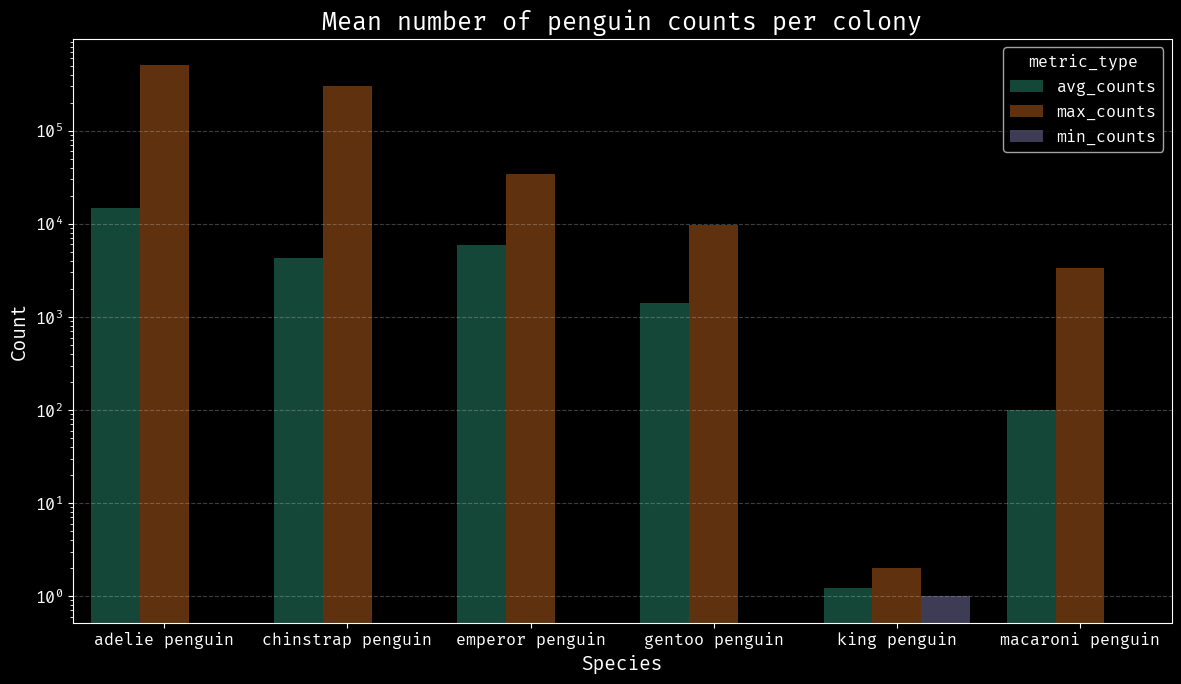

In [187]:
# plotting the data
fig, ax = plt.subplots()

ax = sns.barplot(
    data=penguin_counts_melted, x="common_name", y="count", hue="metric_type", alpha=0.5
)

# labelling
ax.set_title("Mean number of penguin counts per colony")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.set_xlabel("Species")

# displaying
plt.tight_layout()
plt.show()

The data and the resulting plot could lead to the conclusion, that king penguins are loners that travel alone, which would contradict with the definition of penguin colonies, that contain thousands of birds. 

 After some research, the small count can be explained that king penguins breed in the subantarctic islands and northern reaches of the Antarctica and South Georgia. This means that the observed king penguins in the data are just "outliers" who may lost track. 

The next step now is to find out how many colonies of each species are inside the data set.

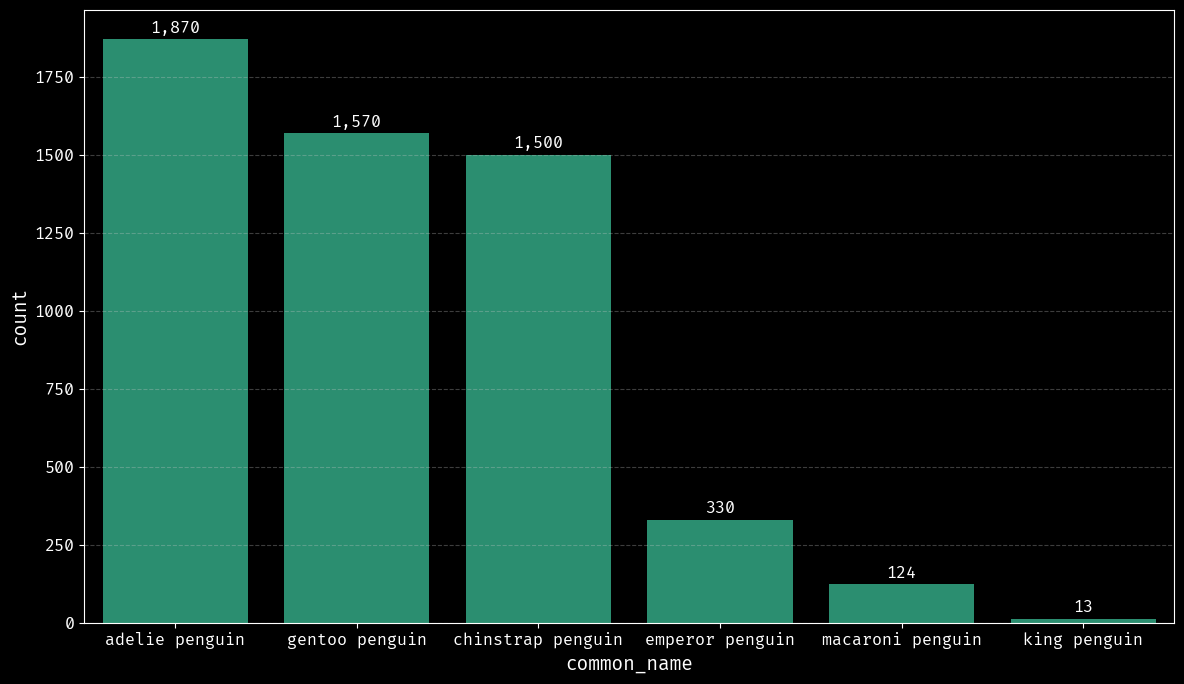

In [203]:
# sorting and counting
colonies_counted = colonies['common_name'].value_counts()

# plotting
fig, ax = plt.subplots()

ax = sns.barplot(data=colonies_counted)


for i, value in enumerate(colonies_counted):
    plt.text(i, value + 20, f'{value:,}', ha='center')

plt.tight_layout()
plt.show()